# skysurvey in 5 minutes

This page walks you through a complete, minimal `skysurvey` simulation. You will draw a population of
Type Ia supernovae (SNe Ia), build a simple mock survey, combine both into a simulated dataset of
lightcurves, and measure which fraction of the supernovae your survey detects as a function of redshift.

The logic of `skysurvey` always follows the same pattern: **Target + Survey → DataSet**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely import geometry

import skysurvey

## 1. Draw targets, as given by nature

A *target* is a population of astrophysical objects with physically motivated properties.
{class}`skysurvey.SNeIa` is a ready-to-use target: {meth}`~skysurvey.SNeIa.from_draw` draws redshifts
following the SN Ia volumetric rate, SALT2 parameters `x1` (stretch) and `c` (color), absolute and observed
magnitudes, a time of maximum light `t0` and sky coordinates.

Here we draw 3 000 SNe Ia up to $z=0.2$, exploding between two dates (`tstart`, `tstop` in MJD), and located in a
patch of sky (the `radec` model entry).

In [2]:
snia = skysurvey.SNeIa.from_draw(size=3_000, zmax=0.2,
                                 tstart=59_000, tstop=59_180,
                                 radec={"ra_range": [150, 250], "dec_range": [-20, 30]})
snia.data.head()

,z,x1,c,t0,ra,dec,magabs,magobs,template
0,0.13055,-0.215,-0.007,59133.023438,211.990952,9.986837,-19.265331,19.743773,salt2
1,0.14635,-0.010,-0.094,59108.835938,210.394455,28.022287,-19.546606,19.732098,salt2
2,0.16685,0.310,0.021,59126.304688,227.138672,12.495574,-19.334911,20.255682,salt2
3,0.18525,-1.385,0.071,59162.257812,242.289841,-5.212762,-18.907911,20.933626,salt2
4,0.19375,1.120,0.068,59115.781250,174.499390,-5.847397,-19.160799,20.788940,salt2


## 2. Build a survey

A *survey* is an observing log (when, where, in which band and under which conditions you observed) plus a
camera footprint. Here we make a mock log of 20 000 random pointings covering the same sky area, in the ZTF
`g`, `r`, `i` bands, starting a month before the first SN and ending two months after the last one.
Each pointing comes with a zero point `zp`, a `gain` and a `skynoise` (background noise, in flux units).

In [3]:
rng = np.random.default_rng(42)
npointings = 20_000
ra, dec = skysurvey.tools.utils.random_radec(size=npointings, ra_range=[150, 250],
                                             dec_range=[-20, 30], rng=rng)
logs = pd.DataFrame({"ra": ra, "dec": dec,
                     "mjd": rng.uniform(58_970, 59_250, size=npointings),
                     "band": rng.choice(["ztfg", "ztfr", "ztfi"], size=npointings),
                     "skynoise": rng.normal(600, 50, size=npointings),
                     "gain": 1, "zp": 30})
logs.head()

,ra,dec,mjd,band,skynoise,gain,zp
0,227.395605,16.363211,59051.597532,ztfg,645.685028,1,30
1,193.887844,29.766662,59003.834217,ztfi,480.815196,1,30
2,235.859792,-17.909622,59000.064408,ztfg,581.422332,1,30
3,219.736803,-7.804480,58972.616178,ztfi,579.523549,1,30
4,159.417735,9.281758,59243.939778,ztfg,576.777318,1,30


{meth}`skysurvey.Survey.from_pointings` combines the log with a footprint, here a circular camera of
2 degrees radius (a [shapely](https://shapely.readthedocs.io) geometry).

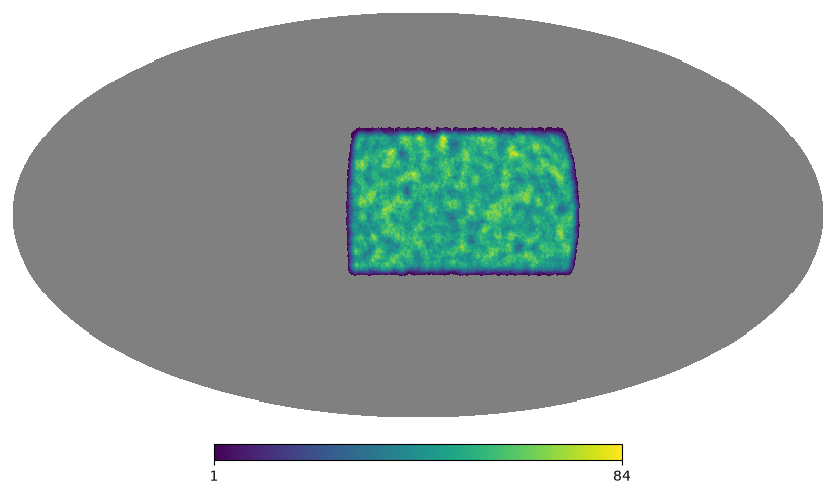

In [4]:
footprint = geometry.Point(0, 0).buffer(2)
survey = skysurvey.Survey.from_pointings(logs, footprint=footprint)
survey.show();

## 3. Observe the targets: create a DataSet

{meth}`skysurvey.DataSet.from_targets_and_survey` matches each target with the survey pointings that observed it
and simulates the corresponding fluxes and flux errors.

In [5]:
dset = skysurvey.DataSet.from_targets_and_survey(snia, survey, seed=42)
dset.data.head()

mjd  band    skynoise  gain  zp  fieldid  \
index index_obs                                                      
0     1174940    59082.656250  ztfi  559.745178     1  30   198728   
      1176979    59082.777344  ztfg  582.518066     1  30   198728   
      1280588    59092.449219  ztfr  589.737000     1  30   198728   
      1331408    59097.316406  ztfg  606.963257     1  30   198728   
      1403316    59104.644531  ztfi  581.132874     1  30   198728   

                        flux     fluxerr  
index index_obs                           
0     1174940     170.563914  559.745171  
      1176979    -605.809544  582.518079  
      1280588     442.568830  589.736991  
      1331408     570.888232  606.963266  
      1403316   -1133.810668  581.132865

`dset.data` is a pandas DataFrame with one row per observation. Its index has two levels: `index`, the target
index in `snia.data`, and `index_obs`, the observation index in `survey.data`.

## 4. Look at a lightcurve

{meth}`~skysurvey.DataSet.show_target_lightcurve` displays the simulated data points of one target on top of
its true (noise-free) lightcurve, one color per band. Fluxes are shown in a zero point 25 system.

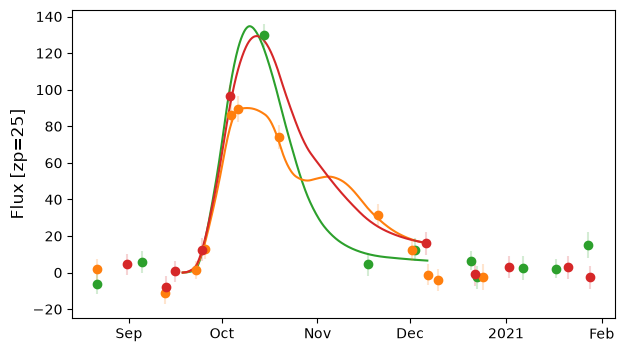

In [6]:
fig = dset.show_target_lightcurve(index=0)

## 5. Which supernovae are detected?

{meth}`~skysurvey.DataSet.get_ndetection` counts, for each target, the observations with a signal-to-noise
ratio `flux/fluxerr` of at least 5. Let us call a SN *detected* when it has at least 5 such points. Targets that
were never observed are missing from the result, so we fill them with 0.

In [7]:
ndet = dset.get_ndetection().reindex(snia.data.index, fill_value=0)
is_detected = ndet >= 5
print(f"{is_detected.mean():.0%} of the SNe Ia are detected.")

72% of the SNe Ia are detected.


Finally, the fraction of detected SNe Ia per redshift bin shows how the survey depth limits the sample:

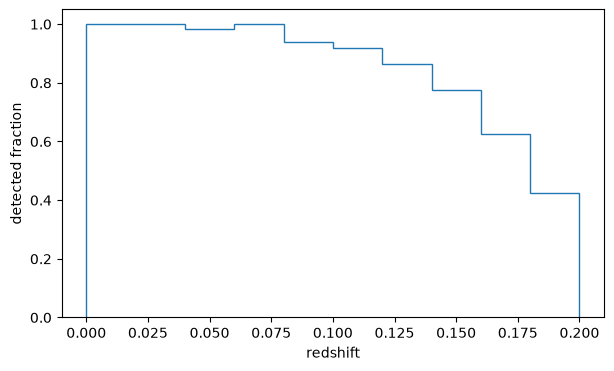

In [8]:
bins = np.linspace(0, 0.2, 11)
n_all, _ = np.histogram(snia.data["z"], bins=bins)
n_det, _ = np.histogram(snia.data["z"][is_detected], bins=bins)

fig, ax = plt.subplots(figsize=(7, 4))
ax.stairs(n_det / n_all, bins)
ax.set(xlabel="redshift", ylabel="detected fraction", ylim=(0, 1.05));

That's it: you simulated a survey of SNe Ia in a few lines of code.

## Next steps

- [Targets](quickstart_target.ipynb): understand what a target is made of (rate, model, template).
- [Surveys](quickstart_survey.ipynb): build surveys with or without pre-defined fields.
- [Datasets](quickstart_survey_target_dataset.ipynb): combine targets and surveys in more detail.
- Browse the [how-to guides](../howto/index.rst) and the [examples](../examples/index.rst) for specific tasks.